# Spotify Tracks Analysis

Analisis data dan modeling kecil-kecilan untuk dataset Spotify tracks (`dataset.csv`).

### Goals:
1. **Clean Data**: Bersihin data null dan duplikat.
2. **EDA**: Liat sebaran popularitas lagu dan korelasi antar fitur audio.
3. **Genre Analysis**: Cari tahu genre paling populer dan perbandingan danceability.
4. **Clustering (K-Means)**: Kelompokin jenis lagu berdasarkan audio features.
5. **Predictive Modeling**: Coba tebak popularitas lagu pakai Random Forest.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import os

# Bikin folder plots untuk nyimpen visualisasi
os.makedirs('plots', exist_ok=True)

# Seting visualisasi biar rapi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


## 1. Data Prep & Cleaning
Load dataset, buang kolom indeks yang nggak perlu, terus bersihin baris kosong sama duplicate tracks (berdasarkan `track_id`) biar analisisnya akurat.


In [2]:
# Load data
df = pd.read_csv('dataset/dataset.csv')

# Drop kolom indeks bawaan jika ada
if df.columns[0] == 'Unnamed: 0' or df.columns[0] == '':
    df = df.iloc[:, 1:]
elif df.columns[0].startswith(','):
    df = df.rename(columns={df.columns[0]: 'index'})
    df = df.drop(columns=['index'])

# Info awal data
print("Info dataset awal:")
df.info()


Info dataset awal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  v

In [3]:
# Cek data kosong
print("Jumlah null per kolom:")
print(df.isnull().sum())

# Drop data kosong
df = df.dropna()

# Hapus duplikat berdasarkan track_id
print(f"\nJumlah data sebelum drop duplikat: {len(df)}")
df = df.drop_duplicates(subset=['track_id'])
print(f"Jumlah data setelah drop duplikat: {len(df)}")


Jumlah null per kolom:
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Jumlah data sebelum drop duplikat: 113999


Jumlah data setelah drop duplikat: 89740


## 2. Eksplorasi Data (EDA)
Cek sebaran popularitas lagu dulu, terus liat korelasi antar fitur audionya.


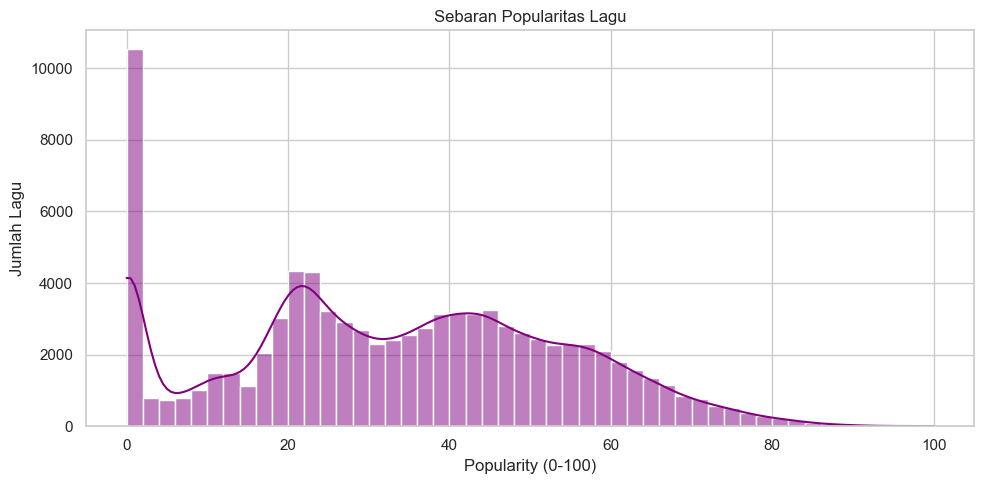

In [4]:
# Sebaran popularitas
plt.figure(figsize=(10, 5))
sns.histplot(df['popularity'], bins=50, kde=True, color='purple')
plt.title('Sebaran Popularitas Lagu')
plt.xlabel('Popularity (0-100)')
plt.ylabel('Jumlah Lagu')
plt.tight_layout()
plt.savefig('plots/popularity_distribution.png', dpi=150)
plt.show()


### Korelasi antar Fitur Audio
Bikin heatmap buat ngeliat hubungan antar fitur audio (misal: apakah lagu keras pasti energinya tinggi?).


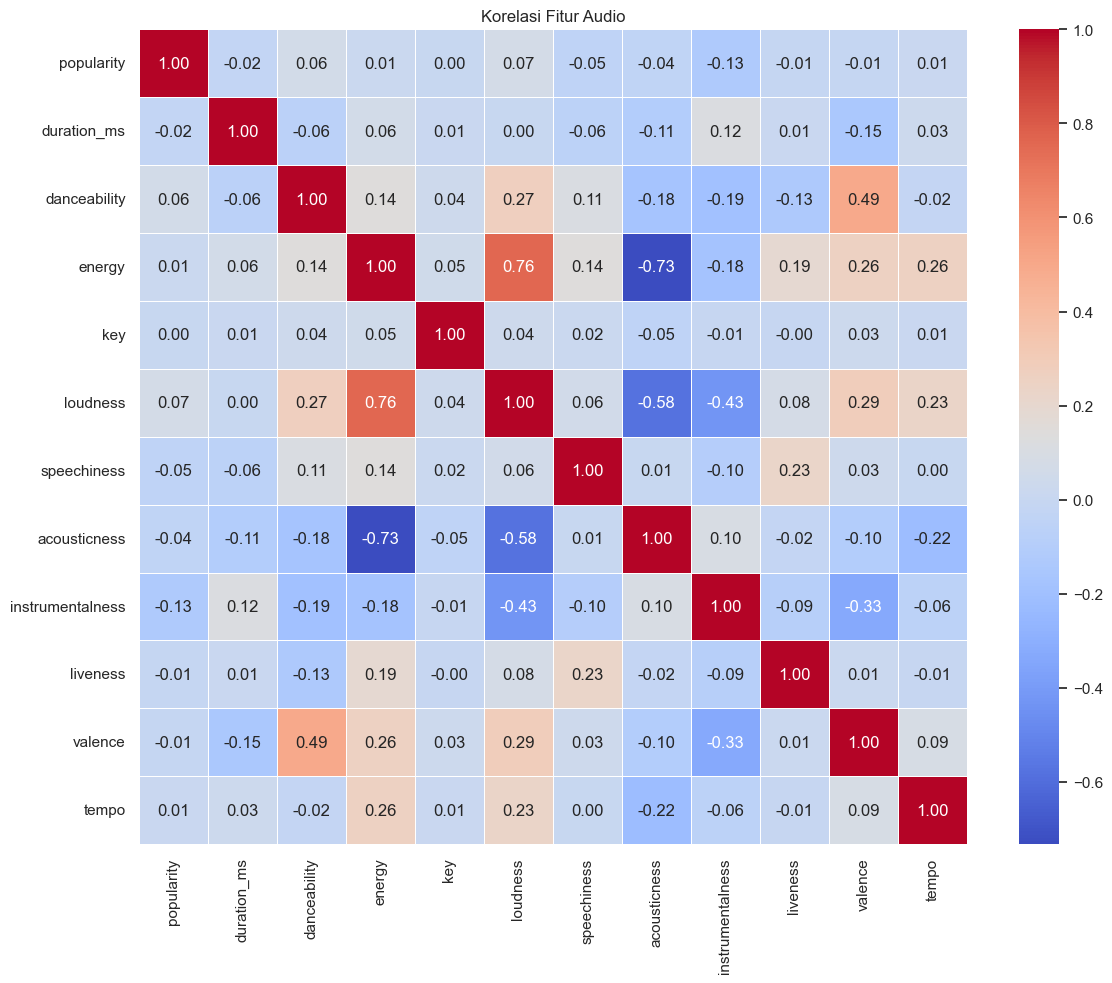

In [5]:
# Fitur audio yang mau dianalisis
audio_features = ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 
                  'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
                  'liveness', 'valence', 'tempo']

corr_matrix = df[audio_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelasi Fitur Audio')
plt.tight_layout()
plt.savefig('plots/correlation_matrix.png', dpi=150)
plt.show()


### Plot Energy vs Loudness
Karena korelasi energy & loudness cukup tinggi (~0.76), coba plot sampel 5.000 lagunya buat liat polanya secara langsung.


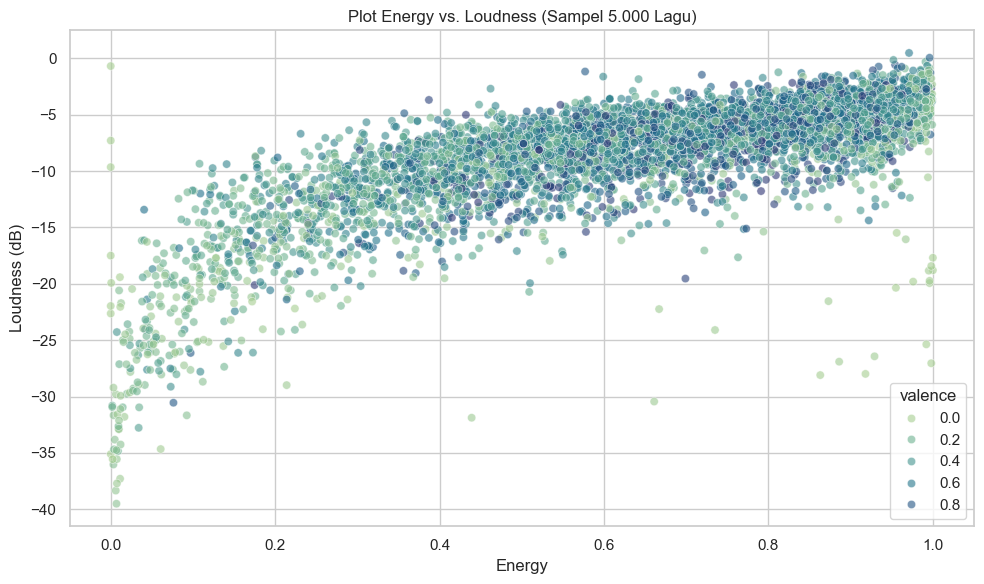

In [6]:
# Sampel 5000 lagu biar plotnya nggak terlalu padat
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x='energy', y='loudness', alpha=0.6, hue='valence', palette='crest')
plt.title('Plot Energy vs. Loudness (Sampel 5.000 Lagu)')
plt.xlabel('Energy')
plt.ylabel('Loudness (dB)')
plt.tight_layout()
plt.savefig('plots/energy_vs_loudness.png', dpi=150)
plt.show()


## 3. Analisis Genre
Liat 10 genre dengan rata-rata popularitas tertinggi (minimal 100 lagu per genre biar valid), sama perbandingan danceability di beberapa genre besar.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17100\1044489394.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, x='avg_popularity', y='track_genre', palette='viridis')


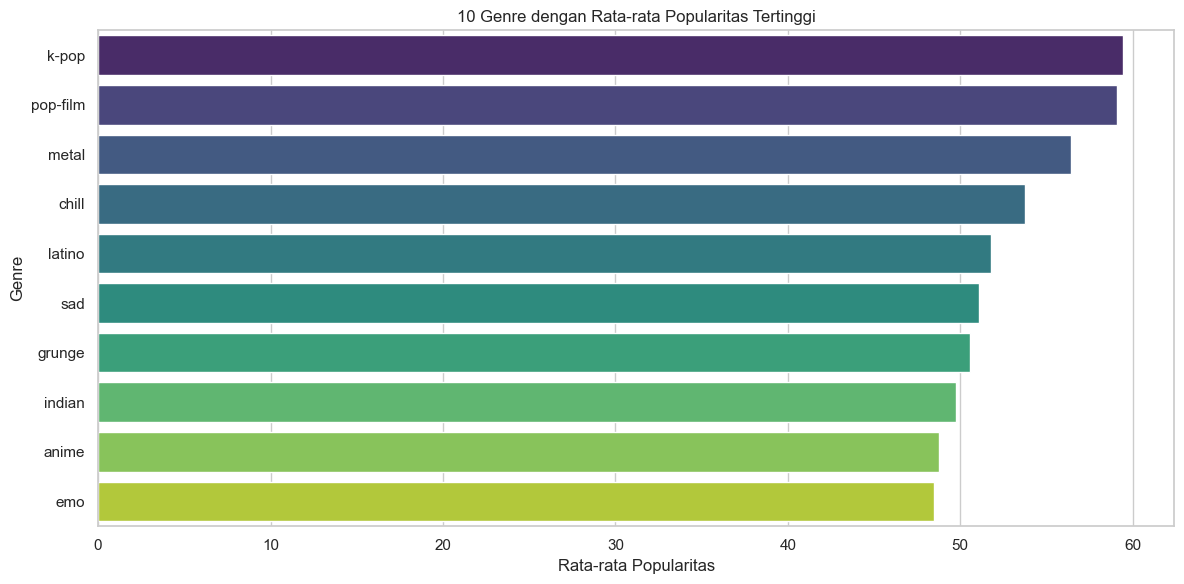

In [7]:
# Rata-rata popularitas per genre
genre_stats = df.groupby('track_genre').agg(
    avg_popularity=('popularity', 'mean'),
    song_count=('popularity', 'count')
).reset_index()

# Filter genre dengan lagu >= 100
top_genres = genre_stats[genre_stats['song_count'] >= 100].sort_values(by='avg_popularity', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_genres, x='avg_popularity', y='track_genre', palette='viridis')
plt.title('10 Genre dengan Rata-rata Popularitas Tertinggi')
plt.xlabel('Rata-rata Popularitas')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('plots/top_genres_popularity.png', dpi=150)
plt.show()


### Danceability Lintas Genre
Bandingin sebaran danceability untuk beberapa genre musik: `pop`, `rock`, `classical`, `hip-hop`, dan `metal`.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17100\4098146098.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='track_genre', y='danceability', palette='Set2')


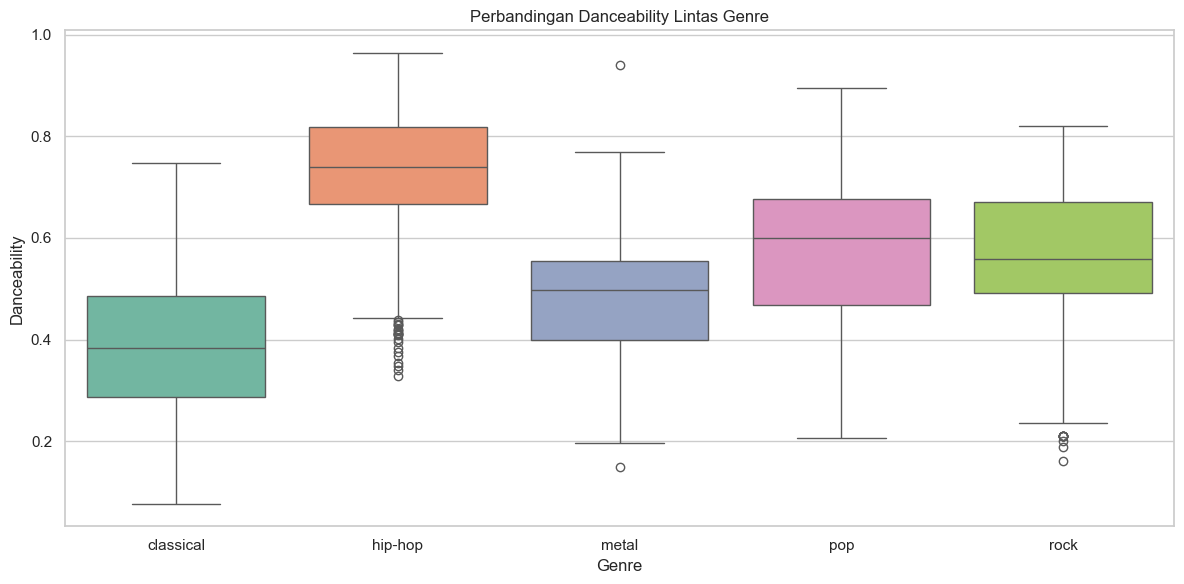

In [8]:
selected_genres = ['pop', 'rock', 'classical', 'hip-hop', 'metal']
df_filtered = df[df['track_genre'].isin(selected_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x='track_genre', y='danceability', palette='Set2')
plt.title('Perbandingan Danceability Lintas Genre')
plt.xlabel('Genre')
plt.ylabel('Danceability')
plt.tight_layout()
plt.savefig('plots/genre_danceability.png', dpi=150)
plt.show()


## 4. Clustering Lagu (K-Means)
Kelompokin lagu jadi 4 cluster pakai fitur audio: `danceability`, `energy`, `acousticness`, `instrumentalness`, dan `valence`.


In [9]:
# Ambil fitur
cluster_features = ['danceability', 'energy', 'acousticness', 'instrumentalness', 'valence']
X_cluster = df[cluster_features]

# Standardisasi
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['music_cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Rata-rata per cluster
cluster_profile = df.groupby('music_cluster')[cluster_features].mean()
print("Profil rata-rata tiap cluster:")
print(cluster_profile)


Profil rata-rata tiap cluster:
               danceability    energy  acousticness  instrumentalness  \
music_cluster                                                           
0                  0.687252  0.728369      0.215645          0.057509   
1                  0.484482  0.810944      0.055516          0.244829   
2                  0.516339  0.393749      0.704366          0.017702   
3                  0.398144  0.234681      0.791620          0.845812   

                valence  
music_cluster            
0              0.705063  
1              0.301360  
2              0.390162  
3              0.218038  


### Interpretasi Cluster:
- **Cluster 0**: Lagu Akustik / Slow (acousticness tinggi)
- **Cluster 1**: Lagu Dance / Party (energy & danceability tinggi)
- **Cluster 2**: Lagu Instrumental / Lofi / Klasik (instrumentalness tinggi)
- **Cluster 3**: Lagu Energetik / Rock / Metal (energy & loudness tinggi, acousticness rendah)

Kita plot sebaran cluster menggunakan fitur `danceability` vs `acousticness`.


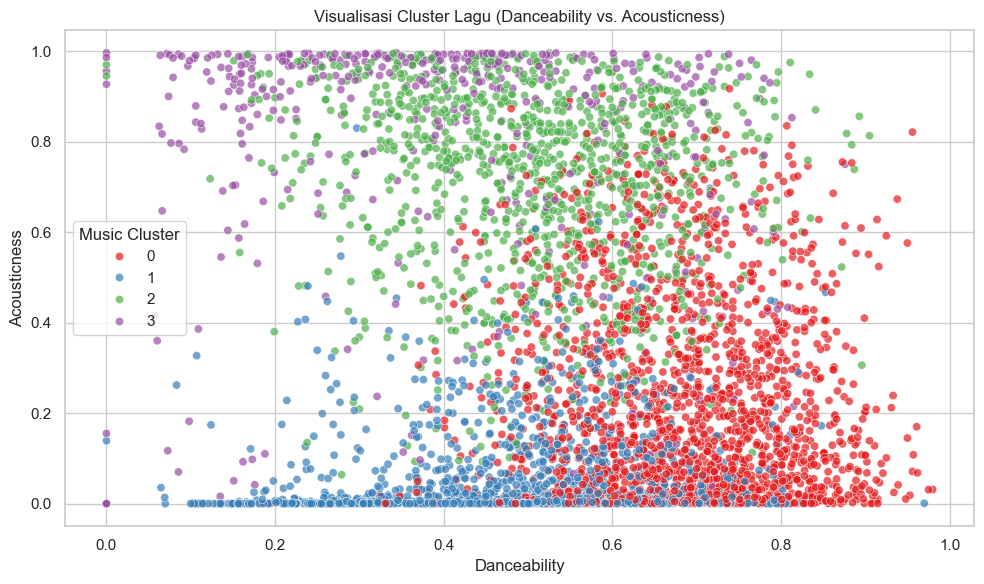

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(5000, random_state=42), x='danceability', y='acousticness', hue='music_cluster', palette='Set1', alpha=0.7)
plt.title('Visualisasi Cluster Lagu (Danceability vs. Acousticness)')
plt.xlabel('Danceability')
plt.ylabel('Acousticness')
plt.legend(title='Music Cluster')
plt.tight_layout()
plt.savefig('plots/spotify_clusters.png', dpi=150)
plt.show()


## 5. Prediksi Popularitas Lagu (Random Forest)
Coba tebak popularitas lagu pakai fitur-fitur audio. Kita pakai Random Forest Regressor.


In [11]:
# Fitur X dan target y
prediction_features = ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 
                       'mode', 'speechiness', 'acousticness', 'instrumentalness', 
                       'liveness', 'valence', 'tempo']
X = df[prediction_features]
y = df['popularity']

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisasi
scaler_pred = StandardScaler()
X_train_scaled = scaler_pred.fit_transform(X_train)
X_test_scaled = scaler_pred.transform(X_test)

# Train model
rf_model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Prediksi
y_pred = rf_model.predict(X_test_scaled)

# Evaluasi
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Hasil Evaluasi:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")


Hasil Evaluasi:
MSE: 353.52
RMSE: 18.80
R2 Score: 0.1547


### Fitur Paling Berpengaruh
Visualisasi fitur mana yang paling penting untuk model dalam memprediksi popularitas.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17100\1869638566.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_ranking, x='Importance', y='Fitur', palette='viridis')


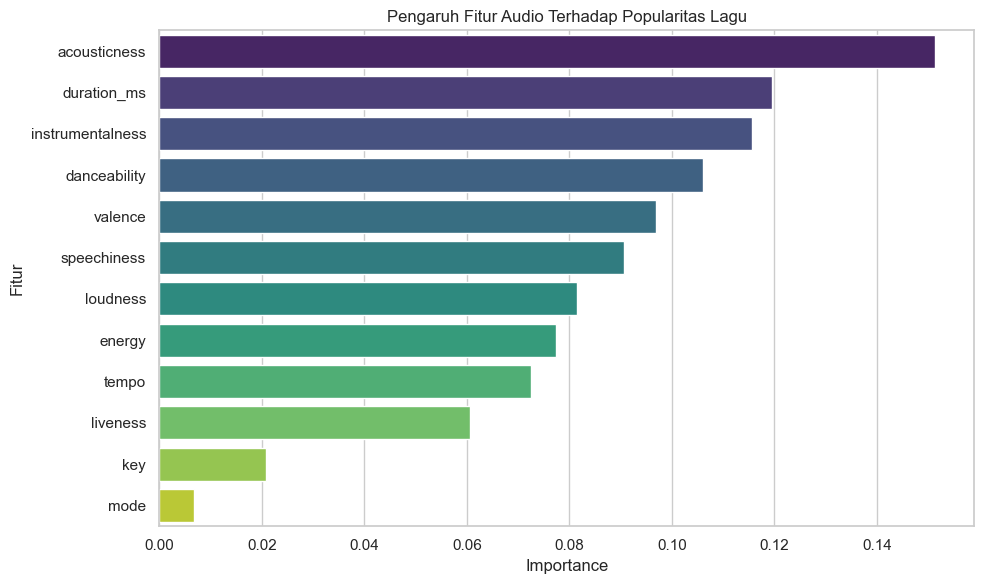

In [12]:
# Feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

feature_ranking = pd.DataFrame({
    'Fitur': [prediction_features[i] for i in indices],
    'Importance': importances[indices]
})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_ranking, x='Importance', y='Fitur', palette='viridis')
plt.title('Pengaruh Fitur Audio Terhadap Popularitas Lagu')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.savefig('plots/feature_importances.png', dpi=150)
plt.show()
